[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Multilayer Perceptrons

Softmax regression allowed us to
train classifiers capable of recognizing
10 categories of clothing from low-resolution images.
Along the way, we learned how to wrangle data,
coerce our outputs into a valid probability distribution,
apply an appropriate loss function,
and minimize it with respect to our model's parameters.
Now that we have mastered these mechanics
in the context of simple linear models,
we can launch our exploration of deep neural networks, the primary topic of this course.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import torch
from matplotlib import pyplot as plt
import numpy as np

## The Limitations of Linear Models

Our softmax regression model maps inputs directly to outputs
via a single affine transformation (linear transformation + bias),
followed by the softmax operation.
If our labels truly were related to the input data by a simple affine transformation,
then this approach would be sufficient.
However, linearity is a *strong* assumption.

For example, linearity implies the *weaker* assumption of *monotonicity*, i.e.,
that any increase in our feature must
either always cause an increase in our model's output
(if the corresponding weight is positive),
or always cause a decrease in our model's output
(if the corresponding weight is negative).
Sometimes that makes sense.
For example, if we were trying to predict
whether an individual will repay a loan,
we might reasonably assume that all other things being equal,
an applicant with a higher income
would always be more likely to repay
than one with a lower income.
While monotonic, this relationship likely
is not linearly associated with the probability of
repayment. An increase in income from 0 to 50,000 dollars
likely corresponds to a bigger increase
in likelihood of repayment
than an increase from 1 million to 1.05 million dollars.
One way to handle this might be to postprocess our outcome
such that linearity becomes more plausible,
by using the logistic map (and thus the logarithm of the probability of outcome).

Note that we can easily come up with examples
that violate monotonicity.
Say for example that we want to predict health as a function
of body temperature.
For individuals with a normal body temperature
above 37°C (98.6°F),
higher temperatures indicate greater risk.
However, if the body temperatures drops
below 37°C, lower temperatures indicate greater risk!
Again, we might resolve the problem
with some clever preprocessing, such as using the distance from 37°C
as a feature.

But what about classifying images of cats and dogs?
Should increasing the intensity
of the pixel at location (13, 17)
always increase (or always decrease)
the likelihood that the image depicts a dog?
Reliance on a linear model corresponds to the implicit
assumption that the only requirement
for differentiating cats and dogs is to assess
the brightness of individual pixels.
This approach is doomed to fail in a world
where inverting an image preserves the category.

And yet despite the apparent absurdity of linearity here,
as compared with our previous examples,
it is less obvious that we could address the problem
with a simple preprocessing fix.
That is, because the significance of any pixel
depends in complex ways on its context
(the values of the surrounding pixels).
While there might exist a representation of our data
that would take into account
the relevant interactions among our features,
on top of which a linear model would be suitable,
we simply do not know how to calculate it by hand.
With deep neural networks, we use observational data
to jointly learn both a representation via hidden layers
and a linear predictor that acts upon that representation.

For linear classification models the decision boundary between the classes is linear, which is a clear limitation of such models.  Sometimes it's a good solution (see example below), but we need techniques that do not have this limitation.

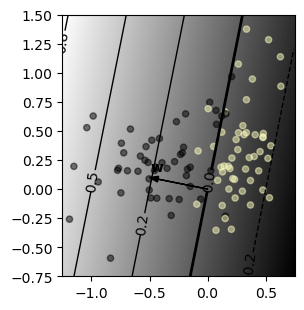

In [2]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, class_sep=0.3, random_state=1)
plt.style.use('default')
plt.figure(figsize=(3,5))
plt.scatter(X[:,0], X[:,1], c=1-y, alpha=0.5, s=20, cmap='magma');

w = np.array([-0.5, 0.1])
b = 0
delta = 0.01
xmin=-1.25;xmax=0.75;ymin=-0.75;ymax=1.5
xs = np.arange(xmin, xmax, delta)
ys = np.arange(ymin, ymax, delta)
x_grid, y_grid = np.meshgrid(xs, ys)

Z = w[0] * x_grid + w[1] * y_grid + b
    
im = plt.imshow(Z, origin='lower',
                cmap=plt.cm.gray, extent=(xmin,xmax,ymin,ymax) )

C = plt.contour(x_grid, y_grid, Z, 5, 
                origin='lower',
                linewidths=(1,1,2,1,1),
                colors = 'black')

plt.clabel(C, inline=1, fmt='%1.1f')

plt.arrow(0,0,w[0],w[1], width=0.001,head_width=0.05, length_includes_head=True, alpha=1,linestyle='-',color='k');
plt.text(w[0], w[1]+0.05, r"$\mathbf{w}$");


### How to go from linear to nonlinear models?

There are different ways to go from a linear model to a nonlinear model.  One approach is to transform your data by a nonlinear function in the hope that the resulting features result in data that is amenable to a linear model.  This is the approach that underlies models such as support vector machines (SVMs) (sidenote:  in SVMs nonlinearity can be induced by the choice of a kernel function so that explicit transformation of the data is not necessary).  In neural networks we take a different approach:  the nonlinear transformation is learned as part of the training process.  The model learns how to transform the data to the point that a linear output layer is sufficient to model it.

Let's show how transforming the data that is originally not linearly separable can make it linearly separable.  We'll start with data that mimics the **XOR function**:

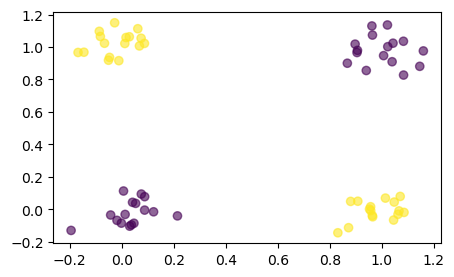

In [3]:
np.set_printoptions(precision=3)

N = 16
sigma = 0.1
rng = np.random.default_rng(42)

Xlst = []
ylst = []
for i in [0,1] :
    for j in [0,1] :
        for k in range(N) :
            Xlst.append([i + sigma * rng.normal(), 
                         j + sigma * rng.normal()])
            ylst.append(i^j)  # ^ is the XOR operator in python
X = np.array(Xlst)         
y = np.array(ylst)
fig = plt.figure(figsize=(5,3))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6);

Clearly, no linear classifier will work well on this data.  Now, let's transform the data into a three dimensional space of monomials of degree 2:

In [4]:
from sklearn.preprocessing import PolynomialFeatures
p_order = 2
poly = PolynomialFeatures(p_order, 
                          include_bias=False, 
                          interaction_only=True)
X_poly = poly.fit_transform(X)
print("original features: ", X[0])
print("polynomial features: ", X_poly[0])
print("original features: ", X[-1])
print("polynomial features: ", X_poly[-1])

original features:  [ 0.03  -0.104]
polynomial features:  [ 0.03  -0.104 -0.003]
original features:  [1.146 0.881]
polynomial features:  [1.146 0.881 1.01 ]


In [5]:
print(X_poly[y==0, 2])
print(X_poly[y==1, 2])

[-3.169e-03  7.058e-03  2.541e-02 -4.043e-04  1.433e-04  6.840e-03
  7.443e-04 -4.017e-03 -3.536e-03 -4.386e-04  1.259e-03 -1.889e-03
  1.508e-03  1.945e-03  1.778e-03 -8.704e-03  7.812e-01  9.458e-01
  1.087e+00  1.035e+00  8.880e-01  8.743e-01  8.968e-01  1.068e+00
  8.046e-01  9.539e-01  1.026e+00  1.132e+00  9.137e-01  1.161e+00
  1.122e+00  1.010e+00]
[-0.047  0.069 -0.01  -0.088  0.078 -0.068  0.012  0.089  0.068  0.031
 -0.141 -0.044 -0.032 -0.095 -0.163  0.017  0.085 -0.045 -0.021 -0.099
  0.045  0.07   0.015 -0.033 -0.069 -0.037  0.043  0.001  0.047 -0.011
 -0.008 -0.12 ]


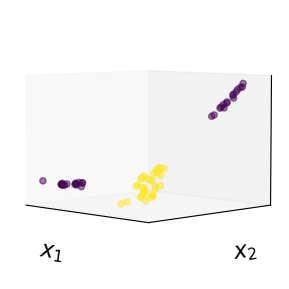

In [6]:
fig = plt.figure(figsize=(5,3.5))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=5, azim=315)
ax.set_xlabel('$x_1$', fontsize=16)
ax.set_ylabel('$x_2$', fontsize=16)
ax.set_zlabel(r'$x_1 \cdot x_2$', fontsize=16)
ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])
ax.axes.get_zaxis().set_ticks([])
ax.scatter(X_poly[:,0],X_poly[:,1],X_poly[:,2],c=y, alpha=0.5);

The resulting three dimensional data has become linearly separable!

While there are transformations that generally work well, the approach of having the classifier learn how to represent the data is an approach that will pay dividends when we move on to discuss deep learning.

## Nonlinear Hidden Layers

We can overcome the limitations of linear models by incorporating one or more hidden layers.
The easiest way to do this is to stack
many fully connected layers on top of one another.
Each layer feeds into the layer above it,
until we generate outputs.
We can think of the first $L-1$ layers
as our representation and the final layer
as our linear predictor.
This architecture is commonly called
a *multilayer perceptron*,
often abbreviated as *MLP*.

In [ ]:
def _fc_network(ax, in_labels, out_labels, x_in=0.0, x_out=2.6, r=0.30,
                dy=0.95, dy_out=None, in_fill='0.92', out_fill='#dce7f2',
                edge_color='0.62', edge_lw=0.7):
    """A fully connected layer: every input circle joined to every output."""
    from matplotlib.patches import Circle

    dy_out = dy if dy_out is None else dy_out
    n_in, n_out = len(in_labels), len(out_labels)
    y_in = [(n_in - 1) / 2 * dy - i * dy for i in range(n_in)]
    y_out = [(n_out - 1) / 2 * dy_out - i * dy_out for i in range(n_out)]

    for yi in y_in:
        for yo in y_out:
            ax.plot([x_in + r, x_out - r], [yi, yo], color=edge_color,
                    linewidth=edge_lw, zorder=1)
    for y, label in zip(y_in, in_labels):
        ax.add_patch(Circle((x_in, y), r, facecolor=in_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_in, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    for y, label in zip(y_out, out_labels):
        ax.add_patch(Circle((x_out, y), r, facecolor=out_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_out, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    return y_in, y_out

def mlp_figure():
    """A one-hidden-layer MLP: 4 inputs, 5 hidden units, 3 outputs."""
    grey, blue = '0.92', '#dce7f2'
    r = 0.24
    dy_in, dy_hid, dy_out = 0.80, 0.68, 0.95
    x_in, x_hid, x_out = 0.0, 2.3, 4.6

    hidden = ['$h_1$', '$h_2$', '$h_3$', '$h_4$', '$h_5$']
    fig, ax = plt.subplots(figsize=(6.10, 4.35))

    y_in, y_hid = _fc_network(ax, ['$x_1$', '$x_2$', '$x_3$', '$x_4$'], hidden,
                              x_in, x_hid, r, dy_in, dy_out=dy_hid,
                              in_fill=grey, out_fill=blue)
    _, y_out = _fc_network(ax, hidden, ['$o_1$', '$o_2$', '$o_3$'],
                           x_hid, x_out, r, dy_hid, dy_out=dy_out,
                           in_fill=blue, out_fill=blue)

    top = max(max(y_in), max(y_hid), max(y_out)) + r
    for x, name, sub in [(x_in, 'input layer', '4 inputs'),
                         (x_hid, 'hidden layer', '5 hidden units'),
                         (x_out, 'output layer', '3 outputs')]:
        ax.text(x, top + 0.52, name, ha='center', va='center', fontsize=9,
                fontweight='bold', color='0.3')
        ax.text(x, top + 0.22, sub, ha='center', va='center', fontsize=7.6,
                color='0.45')

    bottom = min(min(y_in), min(y_hid), min(y_out)) - r
    ax.text((x_in + x_out) / 2, bottom - 0.42,
            'both layers are fully connected, so the network is two layers deep '
            '— the input layer computes nothing',
            ha='center', va='center', fontsize=8, color='0.4')

    ax.set_xlim(x_in - 0.75, x_out + 0.75)
    ax.set_ylim(bottom - 0.75, top + 0.80)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

mlp_figure()

This MLP has four inputs, three outputs,
and its hidden layer contains five hidden units.
Since the input layer does not involve any calculations,
producing outputs with this network
requires implementing the computations
for both the hidden and output layers;
thus, the number of layers in this MLP is two.
Note that both layers are fully connected.
Every input influences every neuron in the hidden layer,
and each of these in turn influences
every neuron in the output layer. Alas, we are not quite
done yet.

### From Linear to Nonlinear

As before, we denote by the matrix $\mathbf{X} \in \mathbb{R}^{n \times d}$
a minibatch of $n$ examples where each example has $d$ inputs (features).
For a one-hidden-layer MLP whose hidden layer has $h$ hidden units,
we denote by $\mathbf{H} \in \mathbb{R}^{n \times h}$
the outputs of the hidden layer, which are
*hidden representations*.
Since the hidden and output layers are both fully connected,
we have hidden-layer weights $\mathbf{W}^{(1)} \in \mathbb{R}^{d \times h}$ and biases $\mathbf{b}^{(1)} \in \mathbb{R}^{1 \times h}$
and output-layer weights $\mathbf{W}^{(2)} \in \mathbb{R}^{h \times q}$ and biases $\mathbf{b}^{(2)} \in \mathbb{R}^{1 \times q}$.
This allows us to calculate the outputs $\mathbf{O} \in \mathbb{R}^{n \times q}$
of the one-hidden-layer MLP as follows:

$$
\begin{aligned}
    \mathbf{H} & = \mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}, \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.
\end{aligned}
$$

Note that after adding the hidden layer,
our model now requires us to track and update
additional sets of parameters.
So what have we gained in exchange?
You might be surprised to find out
that---in the model defined above---*we
gain nothing for our troubles*!
The reason is plain.
The hidden units above are given by
an affine function of the inputs,
and the outputs (pre-softmax) are just
an affine function of the hidden units.
An affine function of an affine function
is itself an affine function.
Moreover, our linear model was already
capable of representing any affine function.

To see this formally we can just collapse out the hidden layer in the above definition,
yielding an equivalent single-layer model with parameters
$\mathbf{W} = \mathbf{W}^{(1)}\mathbf{W}^{(2)}$ and $\mathbf{b} = \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}$:

$$
\mathbf{O} = (\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})\mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W}^{(1)}\mathbf{W}^{(2)} + \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W} + \mathbf{b}.
$$

In order to realize the potential of multilayer architectures,
we need one more key ingredient: a
**nonlinear activation function** $\sigma$
to be applied to each hidden unit
following the affine transformation. For instance, a popular
choice is the ReLU (rectified linear unit) activation function 
$$\sigma(x) = \mathrm{max}(0, x)$$ 

This function operates on its arguments elementwise.
The outputs of activation functions $\sigma(\cdot)$
are called *activations*.
Our network now becomes:

$$
\begin{aligned}
    \mathbf{H} & = \sigma(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}), \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.\\
\end{aligned}
$$

Since each row in $\mathbf{X}$ corresponds to an example in the minibatch,
with some abuse of notation, we define the nonlinearity
$\sigma$ to apply to its inputs in a rowwise fashion,
i.e., one example at a time.
Note that we used the same notation for softmax
when we denoted a rowwise operation.
Quite frequently the activation functions we use apply not merely rowwise but
elementwise. That means that after computing the linear portion of the layer,
we can calculate each activation
without looking at the values taken by the other hidden units.

To build more general MLPs, we can stack
such hidden layers.  For example, we can create a network with two hidden layers:

$$\mathbf{H}^{(1)} = \sigma_1(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})$$

$$\mathbf{H}^{(2)} = \sigma_2(\mathbf{H}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}).$$

Stacking layers in this way yields models that are potentially more expressive.

### Universal Approximation

We know that the brain is capable of very sophisticated computation. As such,
it is worth asking, just *how powerful* a deep network could be. This question
has been answered multiple times, showing that even with a single-hidden-layer network,
given enough nodes (possibly absurdly many),
and the right set of weights,
we can model any function.
Actually learning that function is the hard part, though.
You might think of your neural network
as being a bit like the C programming language.
The language, like any other modern language,
is capable of expressing any computable program.
But actually coming up with a program
that meets your specifications is the hard part.

Moreover, just because a single-hidden-layer network
*can* learn any function
does not mean that you should try
to solve all of your problems
with one. 
In fact, we can approximate many functions
much more compactly by using deeper (rather than wider) networks.
We will touch upon more rigorous arguments in subsequent chapters.

## Activation Functions

Activation functions decide whether a neuron should be activated or not by
calculating the weighted sum and further adding bias to it.
They are differentiable operators for transforming input signals to outputs,
while most of them add nonlinearity.
Because activation functions are fundamental to deep learning, let's briefly survey some common ones.

### The ReLU Function

The most popular choice,
due to both simplicity of implementation and
its good performance on a variety of predictive tasks,
is the *rectified linear unit* (*ReLU*) proposed by Nair and Hinton in 2010.
The ReLU function implements a very simple nonlinear transformation:
Given an element $x$, the function is defined
as:

$$\operatorname{ReLU}(x) = \max(x, 0).$$

Informally, the ReLU function retains only positive
elements and discards all negative elements
by setting the corresponding activations to 0.
To gain some intuition, we can plot the function.
As you can see, the activation function is piecewise linear.


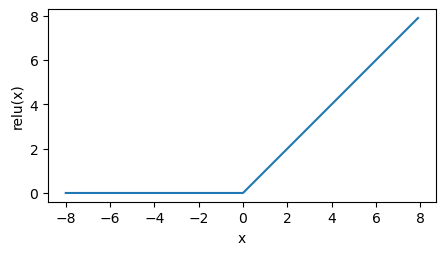

In [7]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('relu(x)');

When the input is negative,
the derivative of the ReLU function is 0,
and when the input is positive,
the derivative of the ReLU function is 1.
Note that the ReLU function is not differentiable
when the input takes value precisely equal to 0.
In these cases, we default to the left-hand-side
derivative and say that the derivative is 0 when the input is 0.
We can get away with this because
the input is unlikely to be exactly zero (mathematicians would
say that it is nondifferentiable on a set of measure zero).
Here is the derivative of the ReLU function:


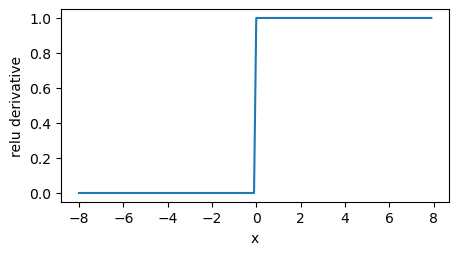

In [8]:
y.backward(torch.ones_like(x))
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('relu derivative');

The reason for using ReLU is that
its derivatives are particularly well behaved:
either they vanish or they just let the argument through.
This makes optimization better behaved
and it mitigated the well-documented problem
of vanishing gradients that plagued
previous versions of neural networks (more on this later).

Note that there are many variants to the ReLU function, including the *Leaky ReLU*.
This variation adds a linear term to ReLU for negative inputs,
so some information still gets through, even when the argument is negative:

$$\operatorname{LeakyReLU}(x) = \max(0, x) + \alpha \min(0, x),$$

where $\alpha$ is a small fixed constant (e.g., 0.01). (When $\alpha$ is
instead *learned* during training, this becomes the *parametric ReLU*, or *PReLU*.)

### The Sigmoid Function

The *sigmoid function* transforms inputs
whose values lie in the domain $\mathbb{R}$,
to outputs that lie on the interval (0, 1).
For that reason, the sigmoid is
often called a *squashing function*:
it squashes an input in the range (-inf, inf)
to a value in the range (0, 1):

$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$

As we have seen, this function is useful for converting arbitrary activations in to numbers that can be interpreted as probabilities.

In the earliest neural networks, scientists
were interested in modeling biological neurons
that either *fire* or *do not fire*.
Thus the pioneers of this field,
going all the way back to McCulloch and Pitts,
the inventors of the artificial neuron,
focused on thresholding units.
A thresholding activation takes value 0
when its input is below some threshold
and value 1 when the input exceeds the threshold.

When attention shifted to gradient-based learning,
the sigmoid function was a natural choice
because it is a smooth, differentiable
approximation to a thresholding unit.
Sigmoids are still widely used as
activation functions on the output units
when we want to interpret the outputs as probabilities
for binary classification problems: you can think of the sigmoid as a special case of the softmax.
However, the sigmoid has largely been replaced
by the simpler and more easily trainable ReLU for most use in hidden layers. 
Much of this has to do with the fact that the sigmoid poses challenges for optimization since its gradient vanishes for large positive *and* negative arguments.
This can lead to plateaus that are difficult to escape from when optimizing the parameters of a network.

Below, we plot the sigmoid function.
Note that when the input is close to 0, the sigmoid function behaves like a linear transformation.


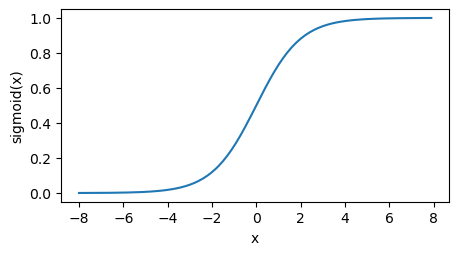

In [9]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('sigmoid(x)');

The derivative of the sigmoid function is given by the following equation:

$$\frac{d}{dx} \operatorname{sigmoid}(x) = \frac{\exp(-x)}{(1 + \exp(-x))^2} = \operatorname{sigmoid}(x)\left(1-\operatorname{sigmoid}(x)\right).$$


The derivative of the sigmoid function is plotted below.
Note that when the input is 0,
the derivative of the sigmoid function
reaches a maximum of 0.25.
As the input diverges from 0 in either direction,
the derivative approaches 0.


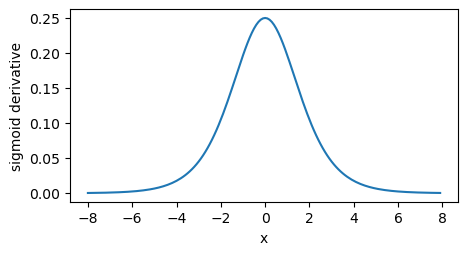

In [10]:
y.backward(torch.ones_like(x))
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('sigmoid derivative');

### The Tanh Function

Like the sigmoid function, the tanh (hyperbolic tangent)
function also squashes its inputs,
transforming them into elements on the interval between $-1$ and $1$:

$$\operatorname{tanh}(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}.$$

We plot the tanh function below. Note that as input nears 0, the tanh function approaches a linear transformation. Although the shape of the function is similar to that of the sigmoid function, the tanh function exhibits point symmetry about the origin of the coordinate system.


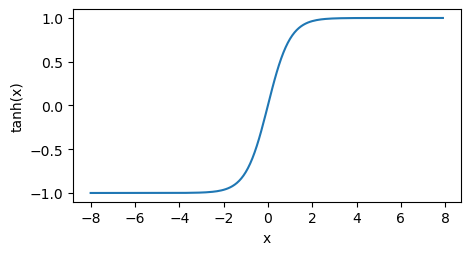

In [11]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('tanh(x)');

The derivative of the tanh function is:

$$\frac{d}{dx} \operatorname{tanh}(x) = 1 - \operatorname{tanh}^2(x).$$

It is plotted below.
As the input nears 0,
the derivative of the tanh function approaches a maximum of 1.
And as we saw with the sigmoid function,
as input moves away from 0 in either direction,
the derivative of the tanh function approaches 0.


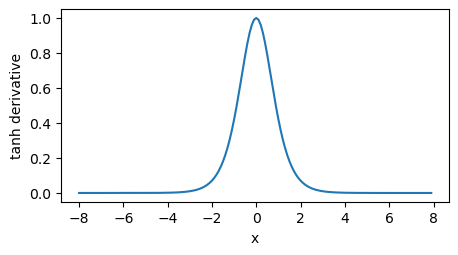

In [12]:
y.backward(torch.ones_like(x))
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('tanh derivative');

## Summary and Discussion

We now know how to incorporate nonlinearities
to build expressive multilayer neural network architectures.
As a side note, your knowledge already
puts you in command of a similar toolkit
to a practitioner circa 1990.
In some ways, you have an advantage
over anyone working back then,
because you can leverage powerful
open-source deep learning frameworks
to build models rapidly, using only a few lines of code.
Previously, training these networks
required researchers to code up layers and derivatives
explicitly in C, Fortran, or even Lisp (in the case of LeNet).

A secondary benefit is that ReLU is significantly more amenable to
optimization than the sigmoid or the tanh function. One could argue
that this was one of the key innovations that helped the resurgence
of deep learning over the past decade. Note, though, that research in
activation functions has not stopped.
For instance, 
the GELU (Gaussian error linear unit)
activation function $x \Phi(x)$ by Hendrycks and Gimpel ($\Phi(x)$
is the standard Gaussian cumulative distribution function) 
and
the Swish activation
function $\sigma(x) = x \operatorname{sigmoid}(\beta x)$ as proposed by Ramachandran, Zoph, and Le can yield better accuracy in many cases.